In [2]:
import pandas as pd
import numpy as np

# 1. Load the two datasets
df1 = pd.read_csv('fake_job_postings.csv')
df2 = pd.read_csv('Fake Postings.csv')

# 2. Inspect column overlap
# df1 has more columns than df2, so we will align them
common_cols = ['title', 'location', 'salary_range', 'company_profile', 
               'description', 'requirements', 'benefits', 'employment_type', 
               'industry', 'fraudulent']

# Create a combined dataframe using common columns
df_combined = pd.concat([df1[common_cols], df2[common_cols]], ignore_index=True)

# 3. Handle Missing Values (Crucial for 99% accuracy)
# We fill NaN with 'Unspecified' so the model can learn from the "absence" of info
df_combined.fillna('Unspecified', inplace=True)

# 4. Create a "Full Text" feature
# To get maximum performance, we combine all text fields into one giant feature
df_combined['text_features'] = (
    df_combined['title'] + " " + 
    df_combined['company_profile'] + " " + 
    df_combined['description'] + " " + 
    df_combined['requirements'] + " " + 
    df_combined['benefits']
)

print("Total samples after merging:", len(df_combined))
print("Class Distribution (0=Real, 1=Fake):")
print(df_combined['fraudulent'].value_counts())

df_combined[['text_features', 'fraudulent']].head()

Total samples after merging: 27880
Class Distribution (0=Real, 1=Fake):
fraudulent
0    17014
1    10866
Name: count, dtype: int64


,text_features,fraudulent
0,"Marketing Intern We're Food52, and we've creat...",0
1,Customer Service - Cloud Video Production 90 S...,0
2,Commissioning Machinery Assistant (CMA) Valor ...,0
3,Account Executive - Washington DC Our passion ...,0
4,Bill Review Manager SpotSource Solutions LLC i...,0


In [3]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Remove non-alphabetic characters (numbers, punctuation, special symbols)
    text = re.sub(r'[^a-zA-Z]', ' ', str(text))
    
    # 2. Convert to lowercase
    text = text.lower().split()
    
    # 3. Lemmatize and remove Stopwords
    text = [lemmatizer.lemmatize(word) for word in text if word not in stop_words]
    
    return ' '.join(text)

# Apply the cleaning function to our combined text feature
print("Cleaning text... this may take a minute.")
df_combined['cleaned_text'] = df_combined['text_features'].apply(clean_text)

print("Text cleaning complete!")
df_combined[['cleaned_text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Cleaning text... this may take a minute.
Text cleaning complete!


,cleaned_text
0,marketing intern food created groundbreaking a...
1,customer service cloud video production second...
2,commissioning machinery assistant cma valor se...
3,account executive washington dc passion improv...
4,bill review manager spotsource solution llc gl...


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# To reach 99% accuracy, we use 'ngram_range=(1,2)' 
# This helps the model learn pairs of words like "urgent hire" or "bank transfer"
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Convert the text into a numerical matrix
X = tfidf.fit_transform(df_combined['cleaned_text']).toarray()
y = df_combined['fraudulent'].values

print("TF-IDF Vectorization Complete.")
print("Feature Matrix Shape:", X.shape)

TF-IDF Vectorization Complete.
Feature Matrix Shape: (27880, 5000)


In [5]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Split the data into Training and Testing sets (80% Train, 20% Test)
# We split BEFORE SMOTE to ensure the test set remains realistic
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Original training class distribution: {Counter(y_train)}")

# 2. Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Resampled training class distribution: {Counter(y_train_res)}")
print("\nData is now perfectly balanced. The model will be much stronger.")

Original training class distribution: Counter({np.int64(0): 13582, np.int64(1): 8722})
Resampled training class distribution: Counter({np.int64(0): 13582, np.int64(1): 13582})

Data is now perfectly balanced. The model will be much stronger.


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize and Train
print("Starting Logistic Regression training...")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_res, y_train_res)

# Quick check on performance
lr_pred = lr_model.predict(X_test)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print("Done!")

Starting Logistic Regression training...
Logistic Regression Accuracy: 0.9822
Done!


In [8]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Initialize and Train
print("Starting Naive Bayes training...")
nb_model = MultinomialNB()
nb_model.fit(X_train_res, y_train_res)

# Quick check on performance
nb_pred = nb_model.predict(X_test)
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_pred):.4f}")
print("Done!")

Starting Naive Bayes training...
Naive Bayes Accuracy: 0.9706
Done!


In [9]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score

# 1. Initialize and Train
# We wrap LinearSVC in CalibratedClassifierCV so we can get probability scores 
# (confidence levels) for your backend later.
print("Starting SVM training (Fast Linear version)...")
base_svm = LinearSVC(max_iter=2000)
svm_model = CalibratedClassifierCV(base_svm) 
svm_model.fit(X_train_res, y_train_res)

# 2. Quick check on performance
svm_pred = svm_model.predict(X_test)
print(f"SVM Accuracy: {accuracy_score(y_test, svm_pred):.4f}")
print("Done! All three models are now trained.")

Starting SVM training (Fast Linear version)...
SVM Accuracy: 0.9898
Done! All three models are now trained.


--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3432
           1       0.99      0.96      0.98      2144

    accuracy                           0.98      5576
   macro avg       0.98      0.98      0.98      5576
weighted avg       0.98      0.98      0.98      5576



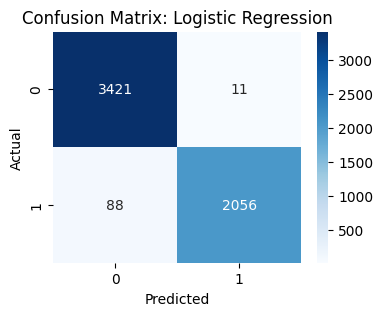



--- Naive Bayes Performance ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      3432
           1       1.00      0.92      0.96      2144

    accuracy                           0.97      5576
   macro avg       0.98      0.96      0.97      5576
weighted avg       0.97      0.97      0.97      5576



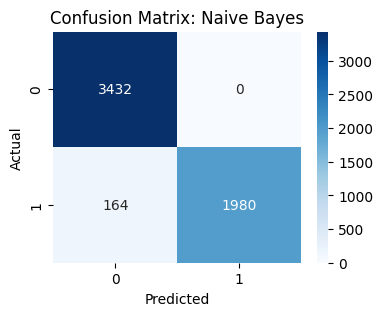



--- SVM (Linear) Performance ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3432
           1       0.99      0.98      0.99      2144

    accuracy                           0.99      5576
   macro avg       0.99      0.99      0.99      5576
weighted avg       0.99      0.99      0.99      5576



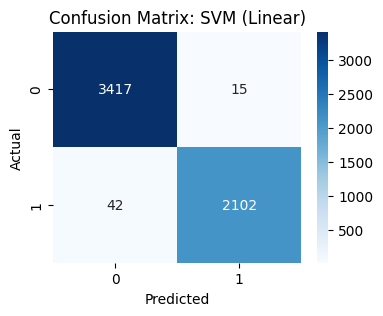

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "SVM (Linear)": svm_model
}

for name, model in models.items():
    predictions = model.predict(X_test)
    print(f"--- {name} Performance ---")
    print(classification_report(y_test, predictions))
    
    # Visualizing the Confusion Matrix for the best view of errors
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print("\n" + "="*40 + "\n")

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Initialize Stratified K-Fold (5 folds is standard for high accuracy)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Evaluate each model
print("Running Stratified K-Fold Cross-Validation...\n")

results = {}
for name, model in models.items():
    # We use 'accuracy' as the scoring metric
    cv_results = cross_val_score(model, X_train_res, y_train_res, cv=skf, scoring='accuracy')
    results[name] = cv_results
    print(f"{name}:")
    print(f"  Mean Accuracy: {cv_results.mean():.4f}")
    print(f"  Standard Deviation: {cv_results.std():.4f}")
    print("-" * 30)

print("\nCross-Validation Complete!")

Running Stratified K-Fold Cross-Validation...

Logistic Regression:
  Mean Accuracy: 0.9823
  Standard Deviation: 0.0010
------------------------------
Naive Bayes:
  Mean Accuracy: 0.9595
  Standard Deviation: 0.0019
------------------------------
SVM (Linear):
  Mean Accuracy: 0.9918
  Standard Deviation: 0.0011
------------------------------

Cross-Validation Complete!


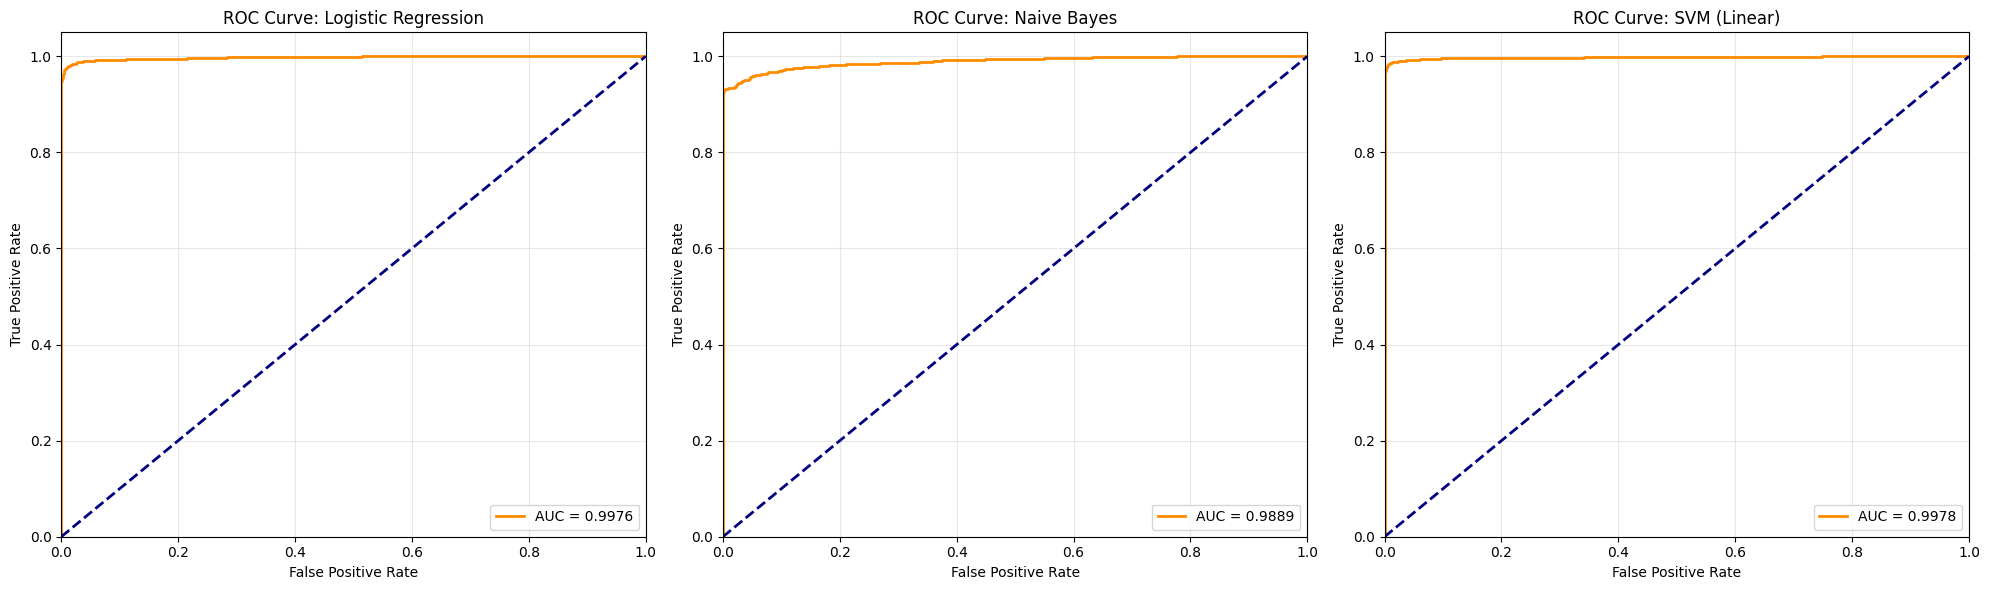

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Define models for evaluation
eval_models = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "SVM (Linear)": svm_model
}

# 2. Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, model) in enumerate(eval_models.items()):
    # Get probabilities for the 'Fake' class
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # Calculate FPR and TPR
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    # Plotting on the specific subplot
    axes[i].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'ROC Curve: {name}')
    axes[i].legend(loc="lower right")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
import pickle

# 1. Save the TF-IDF Vectorizer (The most important part for the backend)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# 2. Save the Trained Models
with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('naive_bayes_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

print("Success! All models and the vectorizer have been saved.")
print("Files created: tfidf_vectorizer.pkl, logistic_regression_model.pkl, naive_bayes_model.pkl, svm_model.pkl")

Success! All models and the vectorizer have been saved.
Files created: tfidf_vectorizer.pkl, logistic_regression_model.pkl, naive_bayes_model.pkl, svm_model.pkl


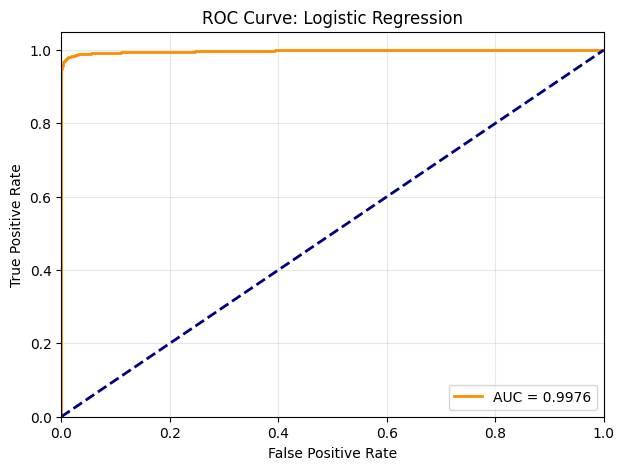

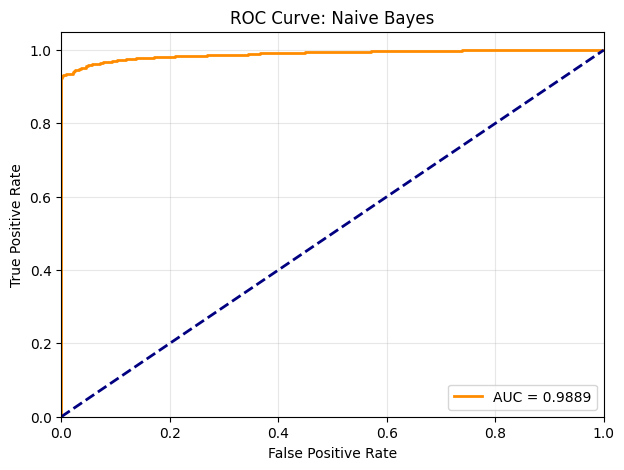

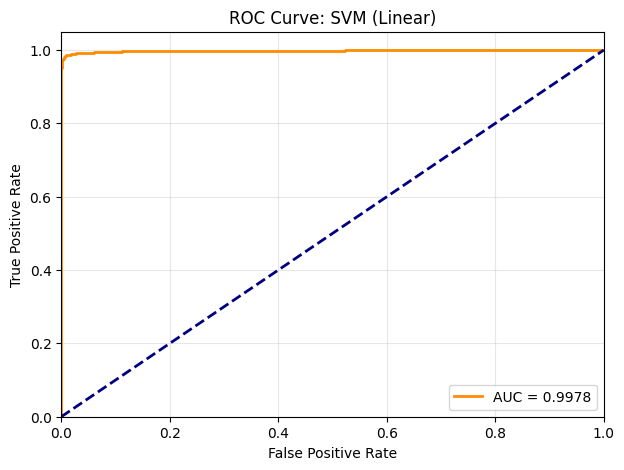

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Define your models (ensure these variables match your notebook)
eval_models = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "SVM (Linear)": svm_model
}

for name, model in eval_models.items():
    # Create a new figure for each model
    plt.figure(figsize=(7, 5))
    
    # Get probabilities for the 'Fake' class
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # Calculate FPR and TPR
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    # Plotting
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {name}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    plt.show() # Display current figure before moving to next model

C:\Users\DELL\AppData\Local\Temp\ipykernel_10772\1247211532.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Real (0)', 'Fake (1)'], y=[before_smote_counts[0], before_smote_counts[1]], palette='viridis')


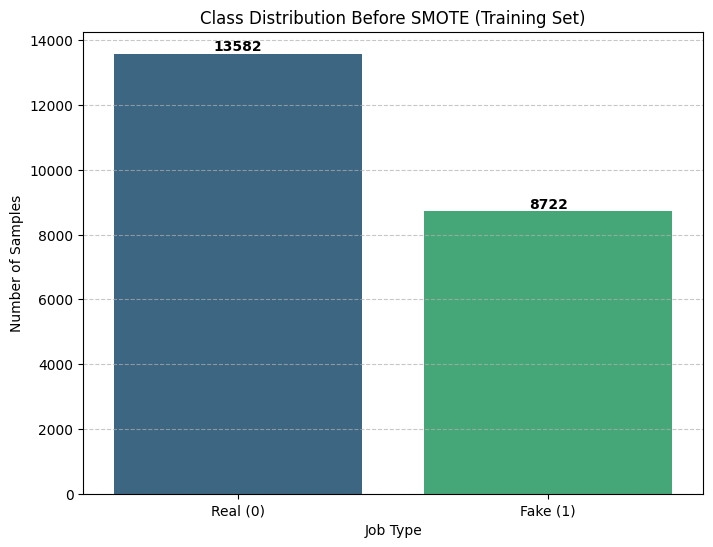

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Distribution from the training data (before SMOTE)
before_smote_counts = Counter(y_train)

plt.figure(figsize=(8, 6))
sns.barplot(x=['Real (0)', 'Fake (1)'], y=[before_smote_counts[0], before_smote_counts[1]], palette='viridis')
plt.title('Class Distribution Before SMOTE (Training Set)')
plt.ylabel('Number of Samples')
plt.xlabel('Job Type')

# Adding text labels on bars
for i, count in enumerate([before_smote_counts[0], before_smote_counts[1]]):
    plt.text(i, count + 100, str(count), ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_10772\3875983136.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Real (0)', 'Fake (1)'], y=[after_smote_counts[0], after_smote_counts[1]], palette='magma')


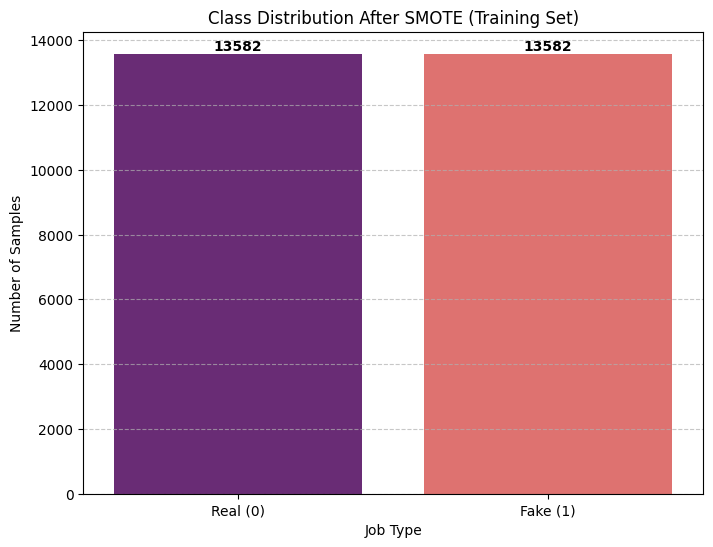

In [16]:
# Distribution after SMOTE
after_smote_counts = Counter(y_train_res)

plt.figure(figsize=(8, 6))
sns.barplot(x=['Real (0)', 'Fake (1)'], y=[after_smote_counts[0], after_smote_counts[1]], palette='magma')
plt.title('Class Distribution After SMOTE (Training Set)')
plt.ylabel('Number of Samples')
plt.xlabel('Job Type')

# Adding text labels on bars
for i, count in enumerate([after_smote_counts[0], after_smote_counts[1]]):
    plt.text(i, count + 100, str(count), ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_10772\2800211350.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(before_smote_acc.keys()), y=list(before_smote_acc.values()), palette="Blues_d")


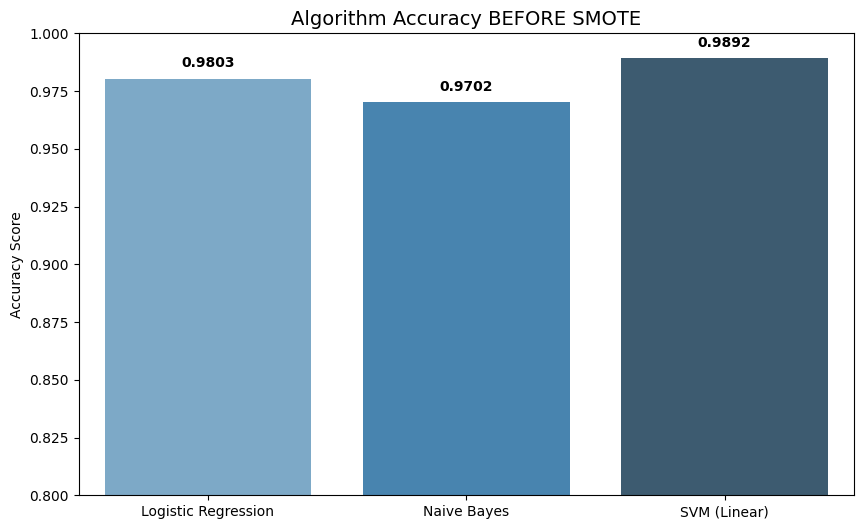

C:\Users\DELL\AppData\Local\Temp\ipykernel_10772\2800211350.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(after_smote_acc.keys()), y=list(after_smote_acc.values()), palette="Greens_d")


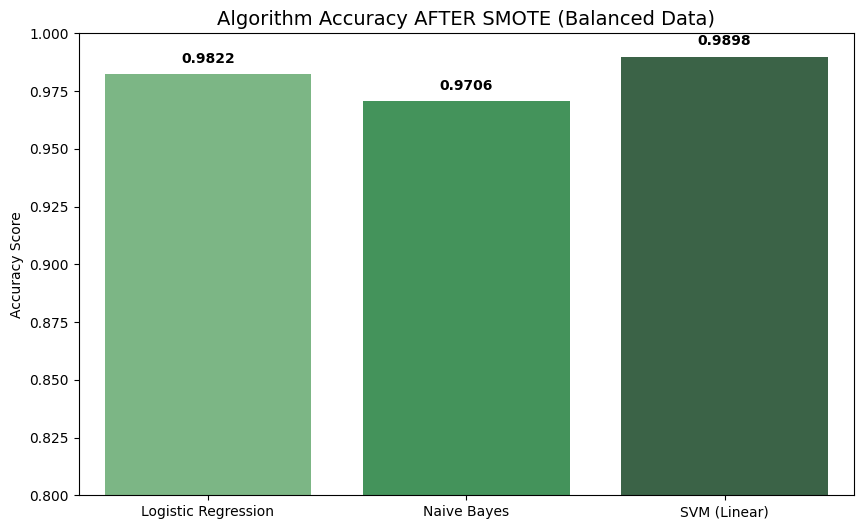

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# 1. Define models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM (Linear)": CalibratedClassifierCV(LinearSVC(max_iter=2000))
}

# 2. Store accuracies
before_smote_acc = {}
after_smote_acc = {}

# Calculate "Before SMOTE" performance
for name, model in models.items():
    model.fit(X_train, y_train) # Training on original imbalanced data
    pred = model.predict(X_test)
    before_smote_acc[name] = accuracy_score(y_test, pred)

# Calculate "After SMOTE" performance
for name, model in models.items():
    model.fit(X_train_res, y_train_res) # Training on resampled data
    pred = model.predict(X_test)
    after_smote_acc[name] = accuracy_score(y_test, pred)

# --- Graph 1: Performance BEFORE SMOTE ---
plt.figure(figsize=(10, 6))
sns.barplot(x=list(before_smote_acc.keys()), y=list(before_smote_acc.values()), palette="Blues_d")
plt.title('Algorithm Accuracy BEFORE SMOTE', fontsize=14)
plt.ylabel('Accuracy Score')
plt.ylim(0.8, 1.0) # Zoomed in to see differences
for i, v in enumerate(before_smote_acc.values()):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

# --- Graph 2: Performance AFTER SMOTE ---
plt.figure(figsize=(10, 6))
sns.barplot(x=list(after_smote_acc.keys()), y=list(after_smote_acc.values()), palette="Greens_d")
plt.title('Algorithm Accuracy AFTER SMOTE (Balanced Data)', fontsize=14)
plt.ylabel('Accuracy Score')
plt.ylim(0.8, 1.0) # Zoomed in to see differences
for i, v in enumerate(after_smote_acc.values()):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()